Libraries imported successfully
Upload Excel dataset


Saving final_hybrid_ipo_dataset.xlsx to final_hybrid_ipo_dataset.xlsx
Loaded file: final_hybrid_ipo_dataset.xlsx
Dataset shape: (389, 31)
Training rows: 377
Prediction rows: 12
LSTM training completed
XGBoost training completed

Model Performance
MAE  : 0.1297
RMSE : 0.1934
R²   : 0.3799
Train R² : 0.3925


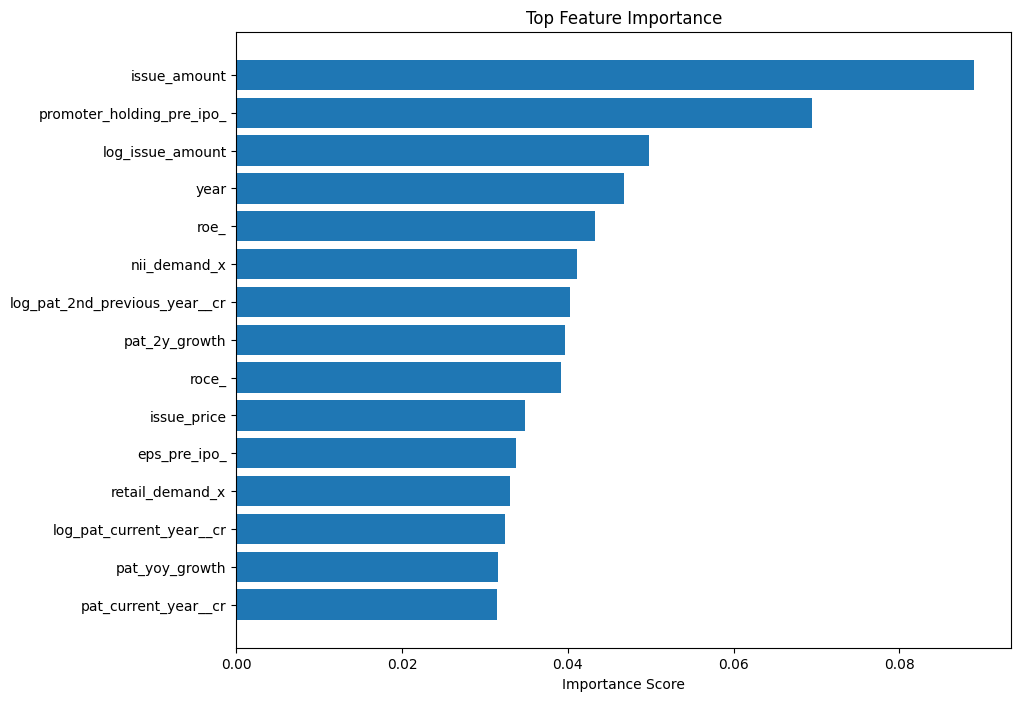

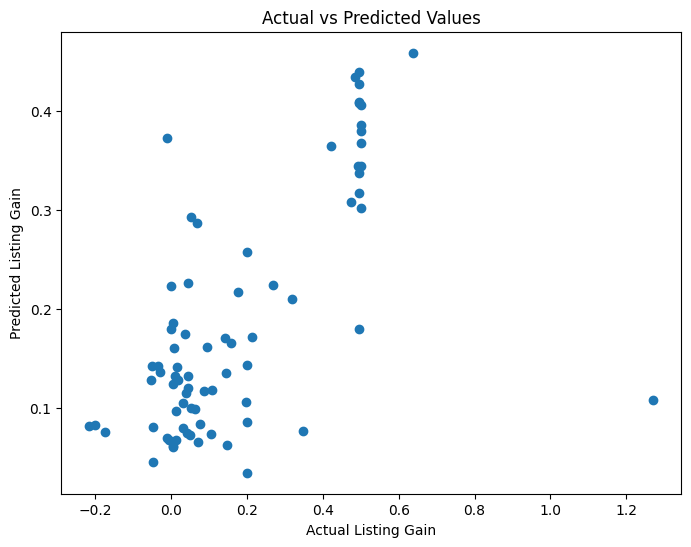


IPO Predictions

IPO: Nfp Sampoorna Foods Ltd. Ipo
Predicted Gain: 28.09%
Prediction: Strong Profit

IPO: Teamtech Formwork Solutions Ltd. Ipo
Predicted Gain: 28.09%
Prediction: Strong Profit

IPO: Vegorama Punjabi Angithi Ltd. Ipo
Predicted Gain: 28.09%
Prediction: Strong Profit

IPO: Harikanta Overseas Ltd. Ipo
Predicted Gain: 28.09%
Prediction: Strong Profit

IPO: Q-Line Biotech Ltd. Ipo
Predicted Gain: 17.17%
Prediction: Strong Profit

IPO: Autofurnish Ltd. Ipo
Predicted Gain: 28.09%
Prediction: Strong Profit

IPO: Bio Medica Laboratories Ltd. Ipo
Predicted Gain: 28.26%
Prediction: Strong Profit

IPO: M R Maniveni Foods Ltd. Ipo
Predicted Gain: 32.72%
Prediction: Strong Profit

IPO: Yaashvi Jewellers Ltd. Ipo
Predicted Gain: 30.38%
Prediction: Strong Profit

IPO: Smr Jewels Ltd. Ipo
Predicted Gain: 28.09%
Prediction: Strong Profit

IPO: Rajnandini Fashion India Ltd. Ipo
Predicted Gain: 27.31%
Prediction: Strong Profit

IPO: Merritronix Ltd. Ipo
Predicted Gain: 32.72%
Prediction: S

In [4]:
"""
IPO Listing Gain Prediction using LSTM and XGBoost.

This project predicts listing gains for ongoing IPOs using:
- financial fundamentals
- PAT-based profitability metrics
- GMP sentiment
- subscription demand features

Models used:
1. LSTM for PAT sequence learning
2. XGBoost for main regression prediction
"""

# Install required libraries in Google Colab
# !pip install xgboost tensorflow scikit-learn pandas matplotlib numpy openpyxl -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.impute import SimpleImputer

import xgboost as xgb

print("Libraries imported successfully")


# Load dataset
FILE_PATH = None

if FILE_PATH is None:
    from google.colab import files

    print("Upload Excel dataset")

    uploaded = files.upload()

    FILE_PATH = list(uploaded.keys())[0]

    print(f"Loaded file: {FILE_PATH}")


# Read dataset
DF = pd.read_excel(FILE_PATH)

print(f"Dataset shape: {DF.shape}")


# Remove leakage columns
LEAKAGE_COLS = [
    'listing_price',
    'bse_open',
    'bse_high',
    'bse_low',
    'nse_open',
    'nse_high',
    'nse_low',
    'last_trade'
]

DF.drop(
    columns=[c for c in LEAKAGE_COLS if c in DF.columns],
    inplace=True,
    errors='ignore'
)


# Define target column
TARGET = 'listing_gain_'


# Convert target column to numeric
DF[TARGET] = pd.to_numeric(
    DF[TARGET],
    errors='coerce'
)


# Define non-numeric columns
NON_NUMERIC = [
    'company',
    'listing_date',
    'lead_manager'
]


# Convert numeric columns
NUM_COLS = [
    c for c in DF.columns
    if c not in NON_NUMERIC
]

for col in NUM_COLS:

    DF[col] = pd.to_numeric(
        DF[col],
        errors='coerce'
    )


# Replace infinite values
DF.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


# Split listed and ongoing IPOs
train_df = DF[
    DF[TARGET].notna()
].copy()

predict_df = DF[
    DF[TARGET].isna()
].copy()

print(f"Training rows: {len(train_df)}")
print(f"Prediction rows: {len(predict_df)}")


# PAT sequence features for LSTM
PAT_SEQ_COLS = [
    'log_pat_2nd_previous_year__cr',
    'log_pat_previous_year__cr',
    'log_pat_current_year__cr'
]


# Prepare sequence data
imp_lstm = SimpleImputer(strategy='median')
sc_lstm = StandardScaler()


def build_lstm_sequences(data, imp, scaler, fit=False):

    values = data[PAT_SEQ_COLS].values

    if fit:
        values = imp.fit_transform(values)
        values = scaler.fit_transform(values)
    else:
        values = imp.transform(values)
        values = scaler.transform(values)

    return values.reshape(len(values), 3, 1)


# Build LSTM inputs
X_seq_train = build_lstm_sequences(
    train_df,
    imp_lstm,
    sc_lstm,
    fit=True
)

X_seq_predict = build_lstm_sequences(
    predict_df,
    imp_lstm,
    sc_lstm,
    fit=False
)


y_lstm = train_df[TARGET].values


# Split validation data
X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    X_seq_train,
    y_lstm,
    test_size=0.2,
    random_state=42
)


# Build LSTM model
lstm_model = Sequential([
    LSTM(32, input_shape=(3, 1)),
    Dropout(0.25),
    Dense(16, activation='relu'),
    Dropout(0.15),
    Dense(1)
])


# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=0
)


# Train LSTM
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print("LSTM training completed")


# Generate LSTM PAT score
train_df['lstm_pat_score'] = lstm_model.predict(
    X_seq_train,
    verbose=0
).flatten()

predict_df['lstm_pat_score'] = lstm_model.predict(
    X_seq_predict,
    verbose=0
).flatten()


# Prepare XGBoost features
EXCLUDE_COLS = NON_NUMERIC + [TARGET] + LEAKAGE_COLS

FEATURES = [
    c for c in train_df.columns
    if c not in EXCLUDE_COLS
]


# Impute missing values
imp_xgb = SimpleImputer(strategy='median')

X = imp_xgb.fit_transform(train_df[FEATURES])
y = train_df[TARGET].values

X_predict = imp_xgb.transform(predict_df[FEATURES])


# Split validation data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=250,
    learning_rate=0.04,
    max_depth=3,
    subsample=0.75,
    colsample_bytree=0.65,
    reg_alpha=0.8,
    reg_lambda=4.0,
    min_child_weight=8,
    gamma=0.3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)


xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("XGBoost training completed")


# Evaluate model
y_pred = xgb_model.predict(X_test)
y_train_pred = xgb_model.predict(X_train)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)

print("\nModel Performance")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"Train R² : {r2_train:.4f}")


# Feature importance
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)


# Plot feature importance
plt.figure(figsize=(10, 8))

plt.barh(
    importance_df['Feature'].head(15),
    importance_df['Importance'].head(15)
)

plt.gca().invert_yaxis()

plt.title('Top Feature Importance')
plt.xlabel('Importance Score')

plt.show()


# Actual vs predicted graph
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Listing Gain')
plt.ylabel('Predicted Listing Gain')

plt.title('Actual vs Predicted Values')

plt.show()


# Generate predictions for ongoing IPOs
predict_df['predicted_gain'] = xgb_model.predict(X_predict)


# Categorize IPO prediction

def categorize_prediction(gain):

    if gain > 0.10:
        return 'Strong Profit'

    elif gain > 0.03:
        return 'Moderate Profit'

    elif gain >= 0:
        return 'Low/Uncertain'

    else:
        return 'Loss Risk'


predict_df['prediction'] = predict_df['predicted_gain'].apply(
    categorize_prediction
)


# Display predictions
print("\nIPO Predictions")

for _, row in predict_df.iterrows():

    company = str(row['company']).title()

    gain = row['predicted_gain'] * 100

    print(f"\nIPO: {company}")
    print(f"Predicted Gain: {gain:.2f}%")
    print(f"Prediction: {row['prediction']}")


# Save prediction results
predict_df.to_excel(
    'ongoing_ipo_predictions.xlsx',
    index=False
)

print("\nPrediction file saved")
